In [1]:
from getdist import plots, loadMCSamples
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use(
    "/home/guerrini/matplotlib_config/paper.mplstyle"
)

plt.rc('text', usetex=True)

sns.set_palette("husl")

g = plots.get_subplot_plotter(width_inch=30)
g.settings.axes_fontsize=60
g.settings.axes_labelsize=60
g.settings.alpha_filled_add = 0.7
g.settings.legend_fontsize = 60

%matplotlib inline

#SPECIFY DATA DIRECTORY AND DESIRED CHAINS TO ANALYSE
root_dir = "/n09data/guerrini/output_chains/"

roots = [
    "SP_v1.4.6_leak_corr_A_fid_cell",
    "SP_v1.4.6_leak_corr_B_fid_cell",
    "SP_v1.4.6_leak_corr_C_fid_cell",
    "SP_v1.4.6_leak_corr_A_kmax=5Mpc_cell",
    "SP_v1.4.6_leak_corr_A_kmax=1Mpc_cell",
    "SP_v1.4.6_leak_corr_A_small_scales_cell",
    "SP_v1.4.6_leak_corr_A_large_scales_cell",
    "SP_v1.4.6_leak_corr_A_OneCov_cell",
    "SP_v1.4.6_A_fid_cell"
]

legend_labels = [
    r"UNIONS $C_\ell$, Blind A",
    r"UNIONS $C_\ell$, Blind B",
    r"UNIONS $C_\ell$, Blind C",
    r"$k_{\rm max}=5h\,\mathrm{Mpc}^{-1},\ \ell_{\rm max}=2048$",
    r"$k_{\rm max}=1h\,\mathrm{Mpc}^{-1},\ \ell_{\rm max}=500$",
    r"Small Scales only",
    r"Large Scales only",
    r"OneCovariance only",
    r"No leakage correction",
]

colours = [
    "royalblue",
    "crimson",
    "forestgreen",
    "royalblue",
    "royalblue",
    "royalblue",
    "royalblue",
    "royalblue",
    "royalblue",
]


print(roots)

['SP_v1.4.6_leak_corr_A_fid_cell', 'SP_v1.4.6_leak_corr_B_fid_cell', 'SP_v1.4.6_leak_corr_C_fid_cell', 'SP_v1.4.6_leak_corr_A_kmax=5Mpc_cell', 'SP_v1.4.6_leak_corr_A_kmax=1Mpc_cell', 'SP_v1.4.6_leak_corr_A_small_scales_cell', 'SP_v1.4.6_leak_corr_A_large_scales_cell', 'SP_v1.4.6_leak_corr_A_OneCov_cell', 'SP_v1.4.6_A_fid_cell']


In [2]:
# MAKE PARAMNAMES FILE

for root in roots:
    with open(root_dir + '{}/samples_{}.txt'.format('/'+root ,root), "r") as file:
        params = file.readline()[1:].split('\t')[:-4]
        file.close()
 
    with open(root_dir + '{}/getdist_{}.paramnames'.format('/'+root, root), "w") as file:
        for i in range(len(params)):
            if len(params[i].split('--')) > 1:
                file.write(params[i].split('--')[1] + '\n')
            else:
                file.write(params[i].split('--')[0] + '\n')
        file.close()

In [3]:
#READ CHAIN

chains=[]

for root in roots:

    samples = np.loadtxt(root_dir + '{}/samples_{}.txt'.format(root,root))
    print(len(samples))
    if 'nautilus' in root:
        samples = np.column_stack((np.exp(samples[:,-3]),samples[:,-1]-samples[:,-2],samples[:,0:-3]))
    else:
        samples = np.column_stack((samples[:,-1],samples[:,-3],samples[:,0:-4]))
    np.savetxt(root_dir + '{}/getdist_{}.txt'.format(root,root), samples)
    
    chain = g.samples_for_root(root_dir + '{}/getdist_{}'.format(root,root),
                               cache=False,
                               settings={'ignore_rows':0,
                                         'smooth_scale_2D':0.5,
                                         'smooth_scale_1D':0.5})

    chains.append(chain)

1543
/n09data/guerrini/output_chains/SP_v1.4.6_leak_corr_A_fid_cell/getdist_SP_v1.4.6_leak_corr_A_fid_cell.txt
Removed no burn in
1487
/n09data/guerrini/output_chains/SP_v1.4.6_leak_corr_B_fid_cell/getdist_SP_v1.4.6_leak_corr_B_fid_cell.txt
Removed no burn in
1504
/n09data/guerrini/output_chains/SP_v1.4.6_leak_corr_C_fid_cell/getdist_SP_v1.4.6_leak_corr_C_fid_cell.txt
Removed no burn in


1576
/n09data/guerrini/output_chains/SP_v1.4.6_leak_corr_A_kmax=5Mpc_cell/getdist_SP_v1.4.6_leak_corr_A_kmax=5Mpc_cell.txt
Removed no burn in
1365
/n09data/guerrini/output_chains/SP_v1.4.6_leak_corr_A_kmax=1Mpc_cell/getdist_SP_v1.4.6_leak_corr_A_kmax=1Mpc_cell.txt
Removed no burn in
1199
/n09data/guerrini/output_chains/SP_v1.4.6_leak_corr_A_small_scales_cell/getdist_SP_v1.4.6_leak_corr_A_small_scales_cell.txt
Removed no burn in
1496
/n09data/guerrini/output_chains/SP_v1.4.6_leak_corr_A_large_scales_cell/getdist_SP_v1.4.6_leak_corr_A_large_scales_cell.txt
Removed no burn in
1715
/n09data/guerrini/output_chains/SP_v1.4.6_leak_corr_A_OneCov_cell/getdist_SP_v1.4.6_leak_corr_A_OneCov_cell.txt
Removed no burn in
1556
/n09data/guerrini/output_chains/SP_v1.4.6_A_fid_cell/getdist_SP_v1.4.6_A_fid_cell.txt
Removed no burn in


In [4]:
name_list = ['OMEGA_M','ombh2','h0','n_s','SIGMA_8','s_8_input', 'logt_agn','a','m1','bias_1']
label_list = ['\Omega_m', '\omega_b h^2', 'h_0', 'n_s', '\sigma_8', 'S_8', 'log T_{AGN}', 'A_{IA}', 'm_1', '\Delta z_1']

for chain in chains:
    param_names = chain.getParamNames()
    for name, label in zip(name_list, label_list):
        param_names.parWithName(name).label = label

In [5]:
param_values = np.array(["# Expt", "Colour", "S8_Mean", "S8_low", "S8_high",  "sigma_8_Mean", "sigma_8_low", "sigma_8_high", "Omega_m_Mean", "Omega_m_low", "Omega_m_high"])
escaped = np.char.replace(legend_labels, '\\', '\\\\')
for i, chain in enumerate(chains):

    margestats = chain.getMargeStats()
    likestats = chain.getLikeStats()

    s8_stats = margestats.parWithName('S_8')
    sigma8_stats = margestats.parWithName('SIGMA_8')
    omegam_stats = margestats.parWithName('OMEGA_M')

    param_values = np.vstack((
        param_values,
        [
            escaped[i],
            colours[i],
            s8_stats.mean,
            s8_stats.mean-s8_stats.limits[0].lower,
            s8_stats.limits[0].upper-s8_stats.mean,
            sigma8_stats.mean,
            sigma8_stats.mean - sigma8_stats.limits[0].lower,
            sigma8_stats.limits[0].upper - sigma8_stats.mean,
            omegam_stats.mean,
            omegam_stats.mean - omegam_stats.limits[0].lower,
            omegam_stats.limits[0].upper - omegam_stats.mean,
        ]
    ))
print(param_values)
np.savetxt(f"{root_dir}/param_values.txt", param_values, fmt=['%s' for i in range(11)], delimiter=';')

[['# Expt' 'Colour' 'S8_Mean' 'S8_low' 'S8_high' 'sigma_8_Mean'
  'sigma_8_low' 'sigma_8_high' 'Omega_m_Mean' 'Omega_m_low'
  'Omega_m_high']
 ['UNIONS $C_\\\\ell$, Blind A' 'royalblue' '0.842180234640262'
  '0.0632698607174389' '0.06565688701510708' '0.9027826795215442'
  '0.24130286534514145' '0.1853743685961099' '0.2938530269203245'
  '0.13430605578554417' '0.08641377995626576']
 ['UNIONS $C_\\\\ell$, Blind B' 'crimson' '0.8750464413347222'
  '0.07356374560776391' '0.06926715547290241' '0.9252999072039497'
  '0.23632868979348842' '0.19339221968272857' '0.30217363682370274'
  '0.14129484189651143' '0.08817022785836587']
 ['UNIONS $C_\\\\ell$, Blind C' 'forestgreen' '0.8170869677801829'
  '0.05888945523750144' '0.05810270209231905' '0.8955301866737367'
  '0.23468803253073056' '0.22474659009309483' '0.2840675022910708'
  '0.1413573072572306' '0.07657249937841631']
 ['$k_{\\\\rm max}=5h\\\\,\\\\mathrm{Mpc}^{-1},\\\\ \\\\ell_{\\\\rm max}=2048$'
  'royalblue' '0.8378235269884154' '0.06504

In [6]:
# Load the value of the parameters
cosmo = np.loadtxt(f"{root_dir}/param_values.txt",
            dtype={'names': ('Expt', 'colour', 's8_mean', 's8_low', 's8_high', 'sigma8_mean', 'sigma8_low', 'sigma8_high', 'omegam_mean', 'omegam_low', 'omegam_high'),
                   'formats': ('U250', 'U20', 'U20', 'U20', 'U20', 'U20', 'U20', 'U20', 'U20', 'U20', 'U20')}, skiprows=1, delimiter=';')
expt = np.char.replace(cosmo['Expt'], '\\\\', '\\')
colours =  cosmo['colour']
s8_mean = cosmo['s8_mean'].astype(np.float64)
s8_low = cosmo['s8_low'].astype(np.float64)
s8_high = cosmo['s8_high'].astype(np.float64)
sigma8_mean = cosmo['sigma8_mean'].astype(np.float64)
sigma8_low = cosmo['sigma8_low'].astype(np.float64)
sigma8_high = cosmo['sigma8_high'].astype(np.float64)
omegam_mean = cosmo['omegam_mean'].astype(np.float64)
omegam_low = cosmo['omegam_low'].astype(np.float64)
omegam_high = cosmo['omegam_high'].astype(np.float64)

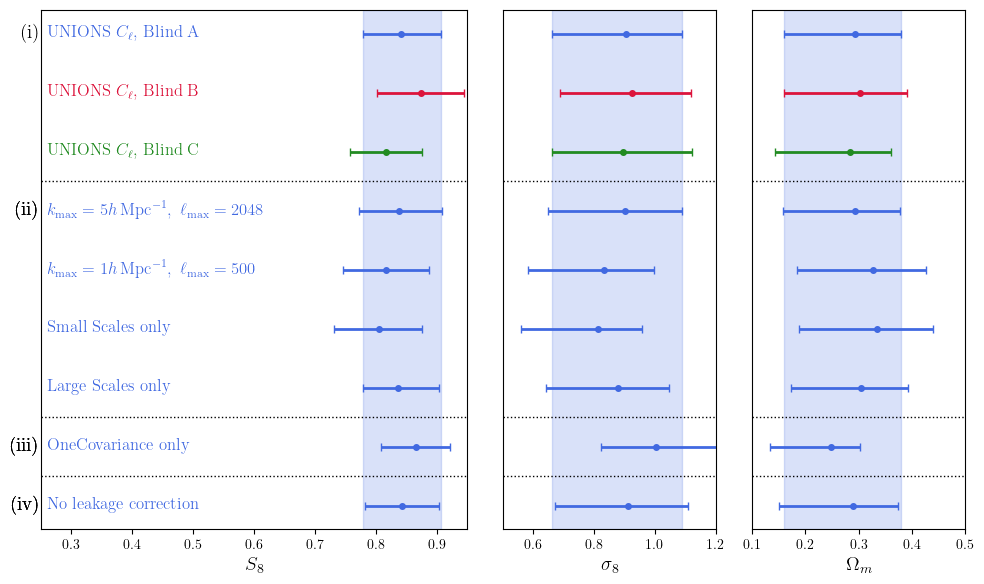

In [11]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(10, 6))
gs = GridSpec(1, 3, width_ratios=[1, 0.5, 0.5])
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharey=ax1)
ax3 = fig.add_subplot(gs[2], sharey=ax1)

axs = [ax1, ax2, ax3]

params = [
    (s8_mean, s8_low, s8_high, r"$S_8$"),
    (sigma8_mean, sigma8_low, sigma8_high, r"$\sigma_8$"),
    (omegam_mean, omegam_low, omegam_high, r"$\Omega_m$"),
]
reference = "UNIONS $C_\ell$, Blind A"
separation_after = [
    r"UNIONS $C_\ell$, Blind C",
    r"Large Scales only",
    r"OneCovariance only"
]
list_section_index = [
    r"(ii)",
    r"(iii)",
    r"(iv)",
    r"(v)",
    r"(vi)",
    r"(vii)"
]
row_spacing = 0.1

index_ref = np.where(expt == reference)[0][0]

y = np.arange(len(expt))
for ax, param in zip(axs, params):
    means, lows, highs, label = param
    for i, mean, low, high, color in zip(y, means, lows, highs, colours):
        ax.errorbar(mean, 0.05+i*row_spacing, xerr=np.array([low, high])[:, None], fmt='o', color=color, ecolor=color, elinewidth=2, capsize=3)
    ax.set_xlabel(label, fontsize=14)
        
    ax.grid(False)
    ax.tick_params(axis='y', left=False, labelleft=False)
    if label == r"$S_8$":
        ax.axvspan(s8_mean[index_ref] - s8_low[index_ref], s8_mean[index_ref] + s8_high[index_ref], color=colours[index_ref], alpha=0.2)
        ax.set_xlim(0.25, 0.95)
    elif label == r"$\sigma_8$":
        ax.axvspan(sigma8_mean[index_ref] - sigma8_low[index_ref], sigma8_mean[index_ref] + sigma8_high[index_ref], color=colours[index_ref], alpha=0.2)
        ax.set_xlim(0.5, 1.2)
    elif label == r"$\Omega_m$":
        ax.axvspan(omegam_mean[index_ref] - omegam_low[index_ref], omegam_mean[index_ref] + omegam_high[index_ref], color=colours[index_ref], alpha=0.2)
        ax.set_xlim(0.1, 0.5)


axs[0].set_yticks(0.05+y*row_spacing)
axs[0].set_yticklabels([])
for label, color in zip(expt, colours):
    axs[0].text(0.26, 0.05 + row_spacing * np.where(expt == label)[0][0], label, fontsize=12, ha='left', va='center', color=color)
# Add separation lines
for i, sep in enumerate(separation_after):
    index_sep = np.where(expt == sep)[0][0]
    for ax in axs:
        ax.axhline(row_spacing * (index_sep + 1), color='black', linestyle='dotted', linewidth=1)
        axs[0].text(0.25, 0.05 + row_spacing * (index_sep + 1), 
            list_section_index[i], fontsize=14, fontweight='bold', va='center', ha='right')


# --- Add section labels (i), (ii)) ---
axs[0].text(0.25, 0.05, 
            r"(i)", fontsize=14, fontweight='bold', va='center', ha='right')


plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig("./plots/whisker_plot.pdf", dpi=300)
plt.show()

In [213]:
list(colours)

['royalblue',
 'crimson',
 'forestgreen',
 'royalblue',
 'royalblue',
 'royalblue',
 'royalblue']